# PCA и повороты — как размерность и базис влияют на бустинг

Исследуем два эффекта на связке **ESM(protein) ‖ GIN(molecule) → XGBoost**:

1. **Сжатие через PCA.** ESM mean (1280-d) проецируется на первые `k` главных
   компонент (PCA обучается **только на train-рецепторах** сплита — без утечки).
   При `k = 409` (число curated-рецепторов) сжатие **почти без потерь**
   (var_kept ≈ 100% на полном датасете, см. `esm_screening.ipynb`) — но базис
   другой (повёрнутый, декоррелированный). При `k < 409` часть дисперсии
   теряется по-настоящему.
2. **Зависимость качества от `k`.** Строим бустинг для набора `k`, выбранных
   логарифмически (гуще у малых значений), и смотрим кривую AUROC/AUPRC(k).

**Важный нюанс про "control" точку.** PCA внутри сплита обучается на train-
рецепторах, которых меньше 1280 (обычно 300-400), поэтому даже запрос
`k=1280` даёт PCA **полного ранга train-подвыборки** (~300-400), а не
буквально нетронутый ESM — это тоже поворот. Поэтому отдельно считаем
**настоящий** сырой ESM (без всякого PCA) как честную опорную точку `k=raw`.

**Гипотеза (из предыдущего анализа):** деревья не инвариантны к повороту базиса
— PCA-409 (почти без потерь по дисперсии) уже показал заметно **более низкое**
качество, чем сырой ESM-1280 (см. заметку `protein-embedding-variants-boost.md`).
Здесь смотрим, что происходит на всём диапазоне `k`, а не в одной точке.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D
from orbind.baselines import make_xy, train_boost

DATA  = ROOT / 'data'
FIG   = ROOT / 'notebooks' / 'protein_embeddings' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / 'notebooks' / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: <repo>


In [ ]:
# --- данные -------------------------------------------------------------
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
_esm_full = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz')
ESM   = {k: v for k, v in _esm_full.items() if k in set(PAIRS['receptor'])}
GIN   = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred.npz')
print(f'pairs={len(PAIRS)} | proteins={len(ESM)} | molecules={len(GIN)}')

N_PROT   = len(ESM)                 # 409 для curated -> максимальный полезный ранг = N_PROT-1
MAX_RANK = N_PROT - 1
print(f'максимальный ранг PCA-базиса на curated: {MAX_RANK}')

## Сетка числа компонент

10 значений `k`, логарифмически распределённых от малого к почти-максимальному
рангу (409 рецепторов -> ранг <= 408) — гуще у малых `k`, где изменения качества
обычно резче.

In [3]:
# --- сетка k (log-spaced, гуще у малых значений) ------------------------
N_POINTS = 10
K_MIN, K_MAX = 4, MAX_RANK - 8   # чуть отступаем от самого края ранга
K_GRID = sorted(set(np.round(np.geomspace(K_MIN, K_MAX, N_POINTS)).astype(int).tolist()))
print(f'k grid ({len(K_GRID)} точек): {K_GRID}')

k grid (10 точек): [4, 7, 11, 19, 31, 52, 86, 144, 240, 400]


## PCA-трансформ, привязанный к train (без утечки)

PCA обучается **только на train-рецепторах** сплита; тем же базисом (среднее +
компоненты) проецируются и train, и test receptors — так что в подгонку PCA
тестовые рецепторы не попадают.

In [4]:
def pca_transform(prot: dict, train_recs: list, k: int) -> dict:
    """Fit PCA on train receptors only; project ALL receptors (train+test)
    into the resulting k-dim basis. No test-set leakage into the PCA fit."""
    keys_all = list(prot.keys())
    X_all    = np.stack([prot[r] for r in keys_all]).astype(np.float64)
    X_train  = np.stack([prot[r] for r in train_recs]).astype(np.float64)

    mu = X_train.mean(0, keepdims=True)
    Xc_train = X_train - mu
    U, S, Vt = np.linalg.svd(Xc_train, full_matrices=False)   # экономичный SVD на train
    kk = min(k, Vt.shape[0])
    comps = Vt[:kk]                                            # [kk, 1280]

    proj = (X_all - mu) @ comps.T                               # [N_all, kk]
    if kk < k:                                                  # паддинг, если ранг train < k
        proj = np.pad(proj, ((0, 0), (0, k - kk)))
    return {r: v.astype(np.float32) for r, v in zip(keys_all, proj)}


def run_pca_boost(pairs, prot, mol, split, k, seed=42, test_size=0.2):
    """split -> fit PCA(k) on train receptors -> assemble X -> boost -> metrics."""
    mask = pairs['receptor'].isin(prot) & pairs['inchikey'].isin(mol)
    p = pairs[mask].reset_index(drop=True)
    y = p['label'].to_numpy(dtype=np.float32)

    tr, te = D.split(p, y, kind=split, test_size=test_size, seed=seed)
    train_recs = p['receptor'][tr].unique().tolist()
    prot_k = pca_transform(prot, train_recs, k)

    X, y2, _ = make_xy(p, prot_k, mol, seed=seed)
    pred = train_boost(X[tr], y2[tr], X[te], seed=seed)
    info = {'train': int(tr.sum()), 'test': int(te.sum()), 'test_pos': int(y2[te].sum())}
    return D.metrics(y2[te], pred), info


def run_raw_boost(pairs, prot, mol, split, seed=42, test_size=0.2):
    """Honest 'no PCA at all' reference: raw ESM straight into the boost."""
    mask = pairs['receptor'].isin(prot) & pairs['inchikey'].isin(mol)
    p = pairs[mask].reset_index(drop=True)
    y = p['label'].to_numpy(dtype=np.float32)
    tr, te = D.split(p, y, kind=split, test_size=test_size, seed=seed)
    X, y2, _ = make_xy(p, prot, mol, seed=seed)
    pred = train_boost(X[tr], y2[tr], X[te], seed=seed)
    info = {'train': int(tr.sum()), 'test': int(te.sum()), 'test_pos': int(y2[te].sum())}
    return D.metrics(y2[te], pred), info

## Дисковый кэш результатов

Тот же формат, что и в `esm_screening.ipynb` / `baseline_screening.ipynb`
(`notebooks/cache/`), но в своём файле — не пересекается с остальными
бейзлайнами.

In [5]:
# --- дисковый кэш --------------------------------------------------------
import json
CFILE = CACHE / 'pca_rotation_screening.json'
_cache = json.loads(CFILE.read_text()) if CFILE.exists() else {}

def _save(): CFILE.write_text(json.dumps(_cache, indent=2))

SPLITS = ['stratified', 'group_molecule', 'group_receptor']
SEED   = 42
SEEDS  = [42, 7, 123]        # три сида -> доверительный интервал (mean ± std)

def cached_pca_run(k, split, seed=SEED, force=False):
    key = f'k{k}|boost|{split}|seed{seed}'
    if key in _cache and not force:
        return _cache[key]
    m, info = run_pca_boost(PAIRS, ESM, GIN, split, k, seed=seed)
    rec = {'k': k, 'split': split, 'seed': seed,
           **{kk: round(float(v), 4) for kk, v in m.items()}, **info}
    _cache[key] = rec; _save()
    return rec

def cached_raw_run(split, seed=SEED, force=False):
    key = f'raw|boost|{split}|seed{seed}'
    if key in _cache and not force:
        return _cache[key]
    m, info = run_raw_boost(PAIRS, ESM, GIN, split, seed=seed)
    rec = {'k': 'raw', 'split': split, 'seed': seed,
           **{kk: round(float(v), 4) for kk, v in m.items()}, **info}
    _cache[key] = rec; _save()
    return rec

## Прогон грида (кэшируется, авто-пропуск готового)

Каждый `k` x 3 сплита, плюс контрольные точки:
- `raw` — сырой ESM без всякого PCA (истинная опорная точка);
- `k = 409` — PCA почти без потерь по дисперсии, но уже повёрнутый базис.

In [6]:
# --- прогон грида (K_GRID + k=N_PROT + raw) x 3 сида -----------------------
rows = []
for seed in SEEDS:
    for k in K_GRID:
        for split in SPLITS:
            rows.append(cached_pca_run(k, split, seed=seed))
    for split in SPLITS:                                # k=N_PROT (почти без потерь)
        rows.append(cached_pca_run(N_PROT, split, seed=seed))
    for split in SPLITS:                                # raw ESM (истинный контроль)
        rows.append(cached_raw_run(split, seed=seed))
    print(f'  seed {seed} готов')

RES = pd.DataFrame(rows).drop_duplicates(subset=['k', 'split', 'seed'], keep='last')
print(f"\nвсего строк: {len(RES)}  ({len(SEEDS)} сида на конфигурацию)")

  seed 42 готов
  seed 7 готов
  seed 123 готов

всего строк: 108  (3 сида на конфигурацию)


## График: качество бустинга vs число PCA-компонент

Ось `k` — логарифмическая. Сплошная линия — PCA-грид; звёздочка `*` в правом
краю — честный сырой ESM (`raw`, без PCA); пунктир отмечает `k=409`
(почти без потерь дисперсии).

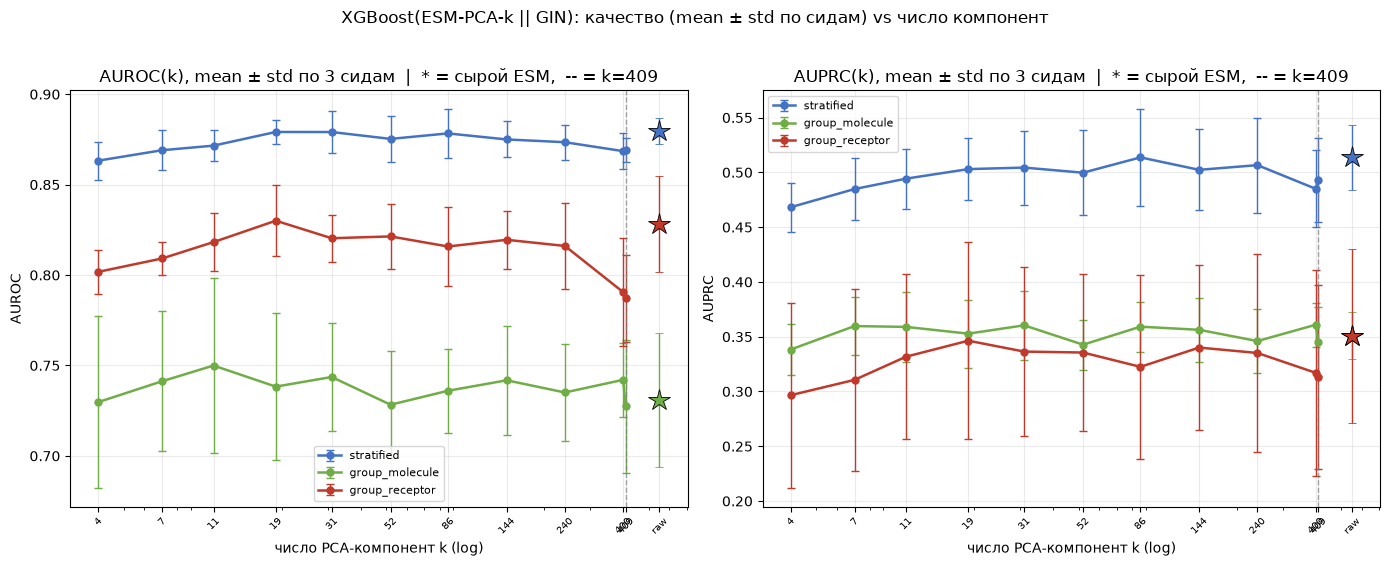

saved -> pca_k_curve.png


In [7]:
# --- график AUROC/AUPRC(k) по сплитам, mean ± std по 3 сидам ---------------
RAW_X = int(MAX_RANK * 1.35)   # позиция звёздочки 'raw' на лог-оси, правее грида
colors = {'stratified': '#4472C4', 'group_molecule': '#70AD47', 'group_receptor': '#C0392B'}

def agg_ms(df, metric):
    g = df.groupby(['k', 'split'])[metric]
    return g.mean().rename('mean').to_frame().join(g.std().rename('std')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for metric, ax in zip(['AUROC', 'AUPRC'], axes):
    A = agg_ms(RES, metric)
    for split in SPLITS:
        sub = A[A['split'] == split]
        num = sub[sub['k'] != 'raw'].assign(k=lambda d: d['k'].astype(int)).sort_values('k')
        ax.errorbar(num['k'], num['mean'], yerr=num['std'], marker='o', color=colors[split],
                    label=split, lw=1.8, ms=5, capsize=3, elinewidth=1)
        raw = sub[sub['k'] == 'raw']
        if not raw.empty:
            ax.errorbar([RAW_X], raw['mean'], yerr=raw['std'], color=colors[split], marker='*',
                        ms=16, mec='k', mew=0.6, capsize=3, elinewidth=1, ls='none', zorder=5)
    ax.axvline(N_PROT, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xticks(list(K_GRID) + [N_PROT, RAW_X])
    ax.set_xticklabels([str(k) for k in K_GRID] + [f'{N_PROT}', 'raw'], rotation=45, fontsize=7)
    ax.set_xlabel('число PCA-компонент k (log)'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}(k), mean ± std по {len(SEEDS)} сидам  |  * = сырой ESM,  -- = k={N_PROT}')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.suptitle('XGBoost(ESM-PCA-k || GIN): качество (mean ± std по сидам) vs число компонент', y=1.02)
fig.tight_layout()
fname = FIG / 'pca_k_curve.png'
fig.savefig(fname, dpi=140, bbox_inches='tight'); plt.show()
print(f'saved -> {fname.name}')

## Таблица результатов

In [8]:
# --- сводная таблица (mean ± std по сидам) -------------------------------
order = [str(k) for k in K_GRID + [N_PROT, 'raw']]

def fmt_table(metric):
    agg = (RES.assign(k=lambda d: d['k'].astype(str))
              .groupby(['k', 'split'])[metric].agg(['mean', 'std']))
    def fmt(r):
        return f"{r['mean']:.3f} ± {r['std']:.3f}" if pd.notna(r['std']) else f"{r['mean']:.3f}"
    return agg.apply(fmt, axis=1).unstack('split').reindex(order)[SPLITS]

print(f'=== AUROC (mean ± std по {len(SEEDS)} сидам) ===')
display(fmt_table('AUROC'))
print(f'=== AUPRC (mean ± std по {len(SEEDS)} сидам) ===')
display(fmt_table('AUPRC'))

=== AUROC (mean ± std по 3 сидам) ===


split,stratified,group_molecule,group_receptor
k,,,
4,0.863 ± 0.011,0.730 ± 0.047,0.802 ± 0.012
7,0.869 ± 0.011,0.741 ± 0.039,0.809 ± 0.009
11,0.872 ± 0.009,0.750 ± 0.048,0.818 ± 0.016
19,0.879 ± 0.006,0.738 ± 0.041,0.830 ± 0.020
31,0.879 ± 0.012,0.744 ± 0.030,0.820 ± 0.013
52,0.875 ± 0.013,0.728 ± 0.030,0.821 ± 0.018
86,0.878 ± 0.013,0.736 ± 0.023,0.816 ± 0.022
144,0.875 ± 0.010,0.742 ± 0.030,0.820 ± 0.016
240,0.873 ± 0.010,0.735 ± 0.027,0.816 ± 0.024


=== AUPRC (mean ± std по 3 сидам) ===


split,stratified,group_molecule,group_receptor
k,,,
4,0.468 ± 0.022,0.338 ± 0.023,0.297 ± 0.085
7,0.485 ± 0.028,0.360 ± 0.027,0.311 ± 0.083
11,0.494 ± 0.027,0.359 ± 0.032,0.332 ± 0.075
19,0.503 ± 0.029,0.353 ± 0.031,0.346 ± 0.090
31,0.504 ± 0.034,0.360 ± 0.031,0.336 ± 0.077
52,0.500 ± 0.039,0.343 ± 0.023,0.336 ± 0.072
86,0.514 ± 0.044,0.359 ± 0.023,0.323 ± 0.084
144,0.502 ± 0.037,0.356 ± 0.029,0.340 ± 0.075
240,0.507 ± 0.043,0.346 ± 0.029,0.335 ± 0.090


---
## full_full: свип числа PCA-компонент **белка** (ESM), молекула = сырой ChemBERTa

Аналог свипа выше, но на датасете **full_full** (ChemBERTa + putative ESM-1b, сплиты LORAX).
Белок сжимаем PCA до `k_prot` (train-fit), молекулу оставляем сырой (ChemBERTa
384-d). Две кривые — по режимам `transductive` / `inductive_molecule`; `raw` =
полный ESM (1280-d).

**Доверительный интервал — по 5 фолдам LORAX** (`rand_split_1..5`), а не по
seed: фолд реально меняет train/test сплит в обоих режимах (в т.ч.
transductive), поэтому `mean ± std` честный. seed=42 фиксирован (cold-mol RNG
у inductive + XGBoost).

⚠ Бустинг на full_full медленный (train ~35–40k пар): PCA-точки ~30–60с/фит,
`raw` (полный ESM) ~2.5 мин/фит. 5 фолдов => заметно дольше, но кэшируется
(твой fold 1 уже посчитан и переиспользуется).

In [9]:
# --- full_full: загрузка данных и хелперы -----------------------------------
# full_full = другой датасет: фичи [ChemBERTa mol (384) || putative ESM-1b mean prot (1280)]
# со сплитами LORAX (orbind.lorax). Два режима: transductive / inductive_molecule.
import json
from orbind import lorax as L

FF_REGIMES = ['transductive', 'inductive_molecule']
FF_FOLDS = [1, 2, 3, 4, 5]                      # 5 фолдов LORAX -> честный CI по данным
FF_SEED  = 42                                   # фикс: cold-mol RNG (inductive) + XGBoost
ESM_FF, CHEM_FF = L.load_embeddings()
print(f'full_full: ESM {next(iter(ESM_FF.values())).shape[0]}-d, '
      f'ChemBERTa {next(iter(CHEM_FF.values())).shape[0]}-d')


def ff_pca_fit_project(X_all, train_idx, k):
    """PCA fit на train-узлах, проекция ВСЕХ узлов в k-мерный базис (без утечки)."""
    if k is None:
        return X_all.astype(np.float32)
    Xtr = X_all[train_idx].astype(np.float64)
    mu = Xtr.mean(0, keepdims=True)
    _, _, Vt = np.linalg.svd(Xtr - mu, full_matrices=False)
    kk = min(k, Vt.shape[0])
    proj = (X_all.astype(np.float64) - mu) @ Vt[:kk].T
    if kk < k:
        proj = np.pad(proj, ((0, 0), (0, k - kk)))
    return proj.astype(np.float32)


def ff_xy(split, Xm, Xp):
    idx = np.concatenate([split['pos'], split['neg']], axis=0)
    y = np.concatenate([np.ones(len(split['pos'])), np.zeros(len(split['neg']))])
    X = np.concatenate([Xm[idx[:, 0]], Xp[idx[:, 1]]], axis=1)
    return X.astype(np.float32), y.astype(np.float32)


def ff_train_node_idx(splits, col):
    tr = np.concatenate([splits['train']['pos'], splits['train']['neg']], axis=0)
    return np.unique(tr[:, col])

FF_CFILE = CACHE / 'pca_rotation_ff_protein.json'
_ff_cache = json.loads(FF_CFILE.read_text()) if FF_CFILE.exists() else {}
def _ff_save(): FF_CFILE.write_text(json.dumps(_ff_cache, indent=1))


# --- сетка k_prot, прогон по (фолд, режим): CI = разброс по 5 фолдам --------
# Усреднение по ФОЛДАМ LORAX, а не по seed: fold реально меняет train/test
# сплит в ОБОИХ режимах (в т.ч. transductive) -> честный доверительный интервал.
FF_K_GRID_PROT = [4, 8, 16, 32, 64, 128, 256]
import time

ff_rows = []
for fold in FF_FOLDS:
    for regime in FF_REGIMES:
        Xm, Xp, splits = L.build(regime, fold, ESM_FF, CHEM_FF, seed=FF_SEED)
        Xm, Xp = Xm.numpy(), Xp.numpy()
        tprot = ff_train_node_idx(splits, col=1)
        for k in FF_K_GRID_PROT + ['raw']:
            key = f'ff|prot|{regime}|k{k}|fold{fold}|s{FF_SEED}'
            if key in _ff_cache:
                ff_rows.append(_ff_cache[key]); continue
            t0 = time.time()
            Xpk = ff_pca_fit_project(Xp, tprot, None if k == 'raw' else k)
            Xtr, ytr = ff_xy(splits['train'], Xm, Xpk)
            Xte, yte = ff_xy(splits['test'],  Xm, Xpk)
            m = D.metrics(yte, train_boost(Xtr, ytr, Xte, seed=FF_SEED))
            rec = {'regime': regime, 'k': k, 'fold': fold,
                   'train': int(len(ytr)), 'test': int(len(yte)),
                   **{kk: round(float(v), 4) for kk, v in m.items()}}
            _ff_cache[key] = rec; _ff_save(); ff_rows.append(rec)
            print(f"  fold{fold} [{regime:<18} k_prot={str(k):>4}] AUROC={rec['AUROC']:.4f} "
                  f"AUPRC={rec['AUPRC']:.4f} ({time.time()-t0:.1f}s)")
    print(f'  fold {fold} готов')

FF_RES = pd.DataFrame(ff_rows)
print(f'\nfull_full (свип белка): {len(FF_RES)} строк ({len(FF_FOLDS)} фолдов на конфигурацию)')

full_full: putative ESM-1b 1280-d, ChemBERTa 384-d
  nodes: 596 molecules, 1237 proteins
  train: 2333 pos / 38493 neg (pos frac 0.057)
  val  : 219 pos / 3953 neg (pos frac 0.052)
  test : 348 pos / 1217 neg (pos frac 0.222)
  nodes: 596 molecules, 1237 proteins | cold mols: 59 test / 29 val of 296 testable
  train: 2035 pos / 32596 neg (pos frac 0.059)
  val  : 94 pos / 206 neg (pos frac 0.313)
  test : 242 pos / 845 neg (pos frac 0.223)
  fold 1 готов
  nodes: 596 molecules, 1237 proteins
  train: 2297 pos / 38529 neg (pos frac 0.056)
... [71 lines omitted] ...
  fold5 [inductive_molecule k_prot=  32] AUROC=0.7571 AUPRC=0.6252 (45.6s)
  fold5 [inductive_molecule k_prot=  64] AUROC=0.7446 AUPRC=0.6015 (55.2s)
  fold5 [inductive_molecule k_prot= 128] AUROC=0.7596 AUPRC=0.6105 (80.8s)
  fold5 [inductive_molecule k_prot= 256] AUROC=0.7630 AUPRC=0.6362 (61.0s)
  fold5 [inductive_molecule k_prot= raw] AUROC=0.7738 AUPRC=0.6246 (164.6s)
  fold 5 готов

full_full (свип белка): 80 строк (5 ф

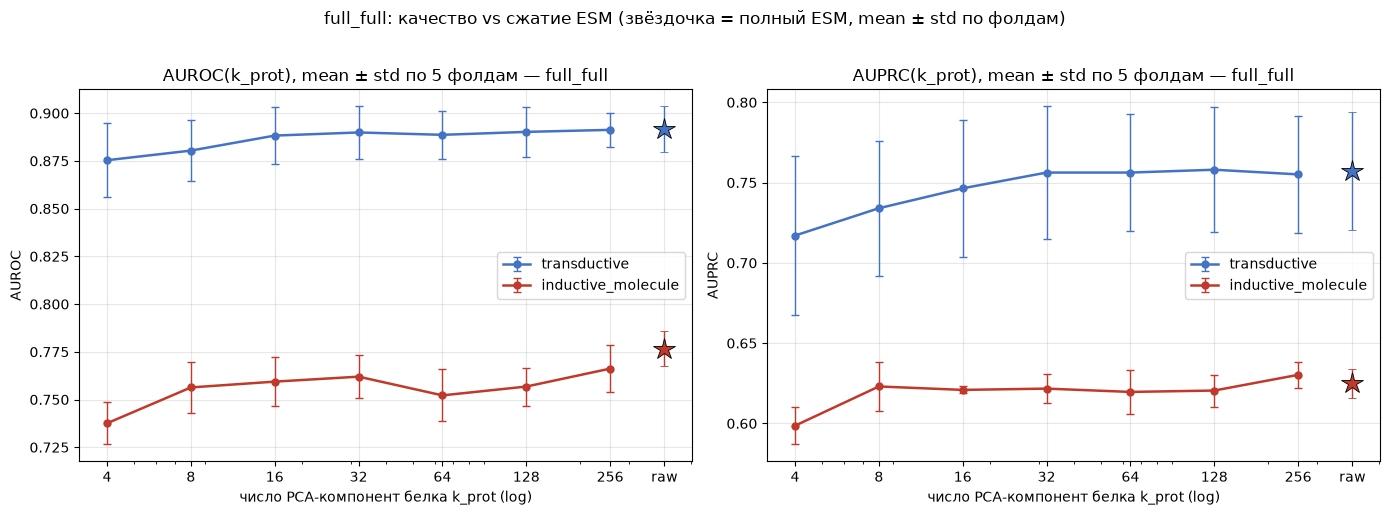

AUROC(k_prot) mean по режимам:


regime,inductive_molecule,transductive
k,,
4,0.7376,0.8754
8,0.7563,0.8804
16,0.7594,0.8883
32,0.7620,0.8899
64,0.7522,0.8887
128,0.7568,0.8902
256,0.7662,0.8913
raw,0.7765,0.8916


In [10]:
# --- график AUROC/AUPRC(k_prot) по режимам, mean ± std по 5 фолдам ----------
RAW_X = 400
col = {'transductive': '#4472C4', 'inductive_molecule': '#C0392B'}

def ff_agg_ms(df, metric):
    g = df.groupby(['k', 'regime'])[metric]
    return g.mean().rename('mean').to_frame().join(g.std().rename('std')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(['AUROC', 'AUPRC'], axes):
    A = ff_agg_ms(FF_RES, metric)
    for regime in FF_REGIMES:
        sub = A[A['regime'] == regime]
        num = sub[sub['k'] != 'raw'].assign(k=lambda d: d['k'].astype(int)).sort_values('k')
        ax.errorbar(num['k'], num['mean'], yerr=num['std'], marker='o', color=col[regime],
                    label=regime, lw=1.8, ms=5, capsize=3, elinewidth=1)
        raw = sub[sub['k'] == 'raw']
        if not raw.empty:
            ax.errorbar([RAW_X], raw['mean'], yerr=raw['std'], color=col[regime], marker='*',
                        ms=16, mec='k', mew=0.6, capsize=3, elinewidth=1, ls='none', zorder=5)
    ax.set_xscale('log')
    ax.set_xticks(FF_K_GRID_PROT + [RAW_X]); ax.set_xticklabels([str(k) for k in FF_K_GRID_PROT] + ['raw'])
    ax.set_xlabel('число PCA-компонент белка k_prot (log)'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}(k_prot), mean ± std по {len(FF_FOLDS)} фолдам — full_full')
    ax.legend(); ax.grid(alpha=.3)
fig.suptitle('full_full: качество vs сжатие putative ESM-1b (звёздочка = полный ESM, mean ± std по фолдам)', y=1.02)
fig.tight_layout(); fig.savefig(FIG / 'ff_pca_k_prot.png', dpi=140, bbox_inches='tight'); plt.show()

order = FF_K_GRID_PROT + ['raw']
tbl = (ff_agg_ms(FF_RES, 'AUROC').assign(k=lambda d: d['k'].astype(str))
       .pivot_table(index='k', columns='regime', values='mean', aggfunc='first')
       .reindex([str(k) for k in order]))
print('AUROC(k_prot) mean по режимам:'); display(tbl.round(4))